#### BPE encoding:

byte-pair encoding: https://en.wikipedia.org/wiki/Byte-pair_encoding

### Attention notes:
- Attention is a *communication mechanism*. Can be seen as nodes in a directed graph looking at each other and aggregating information with a weighted sum from all nodes that point to them, with data-dependent weights.
- There is no notion of space, you have to provide that notion with a position dependent embedding.
- Each example across the batch dimension is processed independently, there is no communication across them, they never "talk" to each other.
- In an encoder attention block -- allow all tokens to communicate with each other. In a decoder block, the mask (tril) is needed so that a token only communicates with the past ones. Eg: Sentiment analysis. Future nodes can't talk to past, otherwise they give away the answer.
- "Self-attention" just means that the keys and values are produced from the same source as queries. In "cross-attention", queries are from x, keys and values are from another source, separate source, nodes on the side with context. cross attention when there is a separate set of nodes where we'd like to pool information from. In principle, attention is very general.
- Normalize Qk(t) by root(dk) so that the attention values do not go into periphery of the softmax function, needed to keep the gradients from getting extremely small. dk = head_size. -- *Scaled Attention*.
- *Causal Attention*: Means the model can only look at the current and past tokens (not the future, can't cheat). This is helpful for generation. Non-causal attention is useful for understanding, classification etc.
- Self attention can't tolerate very high learning rates.

In [1]:
# Tiny shakespeare dataset: https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
# RNN effectiveness: https://karpathy.github.io/2015/05/21/rnn-effectiveness/

# tokenize just means convert the input space (vocabulary, etc) into a sequence of integers.

# !wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
# !wget  https://cs.stanford.edu/people/karpathy/char-rnn/linux.txt

In [12]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import matplotlib.pyplot as plt # for making figures
import numpy as np
%matplotlib inline

In [2]:
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

#with open('linux.txt', 'r', encoding='utf-8') as f:
#    linux_code = f.read()

In [79]:
chars = sorted(list(set(text)))
all_chars = ''.join(chars)

vocab_size = len(chars)

itos = {i:ch for i, ch in enumerate(chars)}
stoi = {ch:i for i, ch in enumerate(chars)}

encoder = lambda s: [stoi[x] for x in s]
decoder = lambda x: ''.join([itos[xx] for xx in x]) 
print(all_chars)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


In [4]:
x1 = encoder("hi there")
print(x1)
print(decoder(x1))

[46, 47, 1, 58, 46, 43, 56, 43]
hi there


In [5]:
# training and val split
data_len = len(text)
split_boundary = int(0.9 * data_len)
encoded_data = torch.tensor(encoder(text))

train_data = encoded_data[:split_boundary]
val_data = encoded_data[split_boundary:]

print(f"number of chars = {data_len}, split boundary = {split_boundary}, length of training data = {len(train_data)}, length of val = {len(val_data)}")


number of chars = 1115394, split boundary = 1003854, length of training data = 1003854, length of val = 111540


In [43]:
batch_size = 32 # how many independent sequences will we process in parallel?
block_size = 8 # what is the maximum context length for predictions? # this is the context length !

torch.manual_seed(1337)

def get_sample_batch(split):
    data = train_data if split == 'train' else val_data

    ix = torch.randint(len(data) - block_size, (batch_size, ))
    xx = [data[i: i + block_size] for i in ix]
    yy = [data[i+1: i + block_size +1] for i in ix]
    return torch.stack(xx), torch.stack(yy)


xx, yy = get_sample_batch('train')

# for x, y in zip(xx, yy):
#     for j in range(len(x)):
#         print(f"when input is {x[:j+1]}    ----->    output is {y[j]}")

#print(xx)
#print(yy)

In [44]:
xx, yy = get_sample_batch('train')
xx.shape, yy.shape

(torch.Size([32, 8]), torch.Size([32, 8]))

In [45]:
vocab_size, xx.size(), yy.size()
xx[1], yy[1]

(tensor([47, 58, 46,  1, 63, 53, 59,  6]),
 tensor([58, 46,  1, 63, 53, 59,  6,  1]))

In [46]:
# hyper params

max_iters = 5000
eval_interval = 500
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embed = 90


In [47]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_sample_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [111]:
def abs_max(w, dim=-1):
    max_abs_val, _ = torch.max(torch.abs(w), dim=dim, keepdim=True)
    normalized_w = w / ( max_abs_val + 1e-9)
    return normalized_w

In [110]:
a = torch.randn((5,3))
print(a)
print(torch.max(a, dim = 1, keepdim=True))


tensor([[ 0.4864, -0.7466,  1.0541],
        [ 0.9003, -0.5409,  0.1593],
        [ 0.6380,  1.1598,  0.5978],
        [-0.0186,  0.9320, -1.4552],
        [-2.1422,  0.9052, -0.0641]])
torch.return_types.max(
values=tensor([[1.0541],
        [0.9003],
        [1.1598],
        [0.9320],
        [0.9052]]),
indices=tensor([[2],
        [0],
        [1],
        [1],
        [1]]))


In [131]:
debug = True

Q_log = []
K_log = []
V_log = []
pre_softmax_weights = []
attn_weights = []

batch_log = []

class Head(nn.Module):
    """ Implements a single head of self-attention"""

    # X = (batch_size, seq_len, embed_dim)
    def __init__(self, embed_dim, head_size, block_size = block_size, is_causal = True):
        super().__init__()
        self.head_size = head_size
        self.embed_dim = embed_dim
        self.block_size = block_size
        self.use_softmax = False

        self.query = nn.Linear(embed_dim, head_size, bias=False)
        self.key = nn.Linear(embed_dim, head_size, bias=False)
        self.value = nn.Linear(embed_dim, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(self.block_size, self.block_size)))
        self.is_causal = is_causal

    def forward(self, x):
        B, T, C = x.shape
        Q = self.query(x)  # B, T, hs
        K = self.key(x)  # B, T, hs
        V = self.value(x) # B, T, hs

        # (B, T, hs) @ (B, hs, T) -> (B, T, T)
        wei = Q @ K.transpose(-2, -1) * (self.head_size ** -0.5)

        
        if self.is_causal:   # mask out the top triangle. 
            if self.use_softmax:
                wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
            else:
                wei = wei.masked_fill(self.tril[:T, :T] == 0, 0.0)
            
        if debug:
            Q_log.append(Q)
            K_log.append(K)
            V_log.append(V)
            pre_softmax_weights.append(wei.view(-1))
            batch_log.append(x.shape)

        #print("before norm", wei)

        if self.use_softmax:
            wei = F.softmax(wei, dim=-1)# (B, T, T)
        else:
            wei = abs_max(wei, dim=-1)
        #print("after norm", wei)
        if debug:
            attn_weights.append(wei.view(-1))
            
        out = wei @ V # (B, T, T) @ (B, T, hs)
        return out #(B, T, hs) or (B, T, C)

#lass MultiheadAttention(nn.Module)
         
         

In [148]:
import torch.nn as nn

# C = number of channels == embedding dim or for hidden layers its the larger last dimension
# T = sequence length or block_size or context_length
# B = batch size or length
# size of that hidden layer
n_hidden = 100

class BigramLM(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embed)
        self.position_embedding = nn.Embedding(block_size, n_embed)
        self.sa_head = Head(n_embed, n_hidden)
        self.lm_head = nn.Linear(n_hidden, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        #print(f"idx.shape = {idx.shape}")
        tok_emb = self.token_embedding_table(idx) # B, T, C = n_embed
        pos_emb = self.position_embedding(torch.arange(T, device=device)) # B, T, C

        x = tok_emb + pos_emb
        #print(f"tok_emb.shape = {tok_emb.shape}, x.shape = {x.shape}")

        x = self.sa_head(x)
        #print(x.shape, tok_emb.shape, pos_emb.shape, idx.shape)
        logits = self.lm_head(x)
        B, T, C = logits.shape

        lg_view = logits
        if targets == None:
            loss = None
        else:
            t = targets.view(B*T)
            lg_view = logits.view(B*T, C)
            loss = F.cross_entropy(lg_view, t)
            
        return lg_view, loss
        
    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices of current context
        print(f"generate() idx.shape = {idx.shape}")
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, loss = self(idx_cond)
            #print(logits, loss)
            # we need the logits only for the last one.
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=1)
            idx_next = torch.multinomial(probs, num_samples=1)
            # print(f"idx shape = {idx.shape}")
            # print(f"idx_cond of shape {idx_cond.shape} = {idx_cond}")
            # print(f"logits = {logits} of shape {logits.shape}, loss ={loss}")
            # print(f"idx_next = {idx_next.shape}, {idx_next}, probs = {probs} of shape {probs.shape}")
            # print(f"size of tensors {idx_next.shape}, {idx.shape}")
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

model = BigramLM(vocab_size)
m = model.to(device)
logits, loss = m(xx, yy)


#print(logits, loss)

#print(decoder(m.generate(torch.zeros((1,1), dtype=torch.long), 100)[0].tolist()))

In [149]:
# create a pytorch optimizer
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-4)

In [150]:
total_params = sum(p.numel() for p in m.parameters())
print(total_params)

40135


In [151]:

for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb = get_sample_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    

# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)


step 0: train loss 4.2642, val loss 4.2808
step 500: train loss 3.0071, val loss 3.0485
step 1000: train loss 2.8297, val loss 2.8424
step 1500: train loss 2.7349, val loss 2.7369
step 2000: train loss 2.6652, val loss 2.6794
step 2500: train loss 2.6257, val loss 2.6359
step 3000: train loss 2.5808, val loss 2.6072
step 3500: train loss 2.5605, val loss 2.5735
step 4000: train loss 2.5319, val loss 2.5619
step 4500: train loss 2.5154, val loss 2.5568


### Loss register
- With softmax step 4999: train loss 2.4386, val loss 2.4399
- With abs_max: step 4999: train loss 2.7674, val loss 2.7874
- Softmax and no pos emb: step 4999: train loss 2.5014, val loss 2.5403

In [152]:
# estimate loss
def print_loss():
    losses = estimate_loss()
    print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

print_loss()

step 4999: train loss 2.5014, val loss 2.5403


### Ledger of architecture and loss values
- Single head, head_size =100, linear layer = 100, block_size = 8
  - 5000 steps: train loss 2.3681, val loss 2.3912
  - attention layers need a lower learning rate 1e-3 

In [138]:
print(decoder(m.generate(context, max_new_tokens=500)[0].tolist()))

generate() idx.shape = torch.Size([1, 1])

3h ne toa sthakluro grisrenll ond houreolirove:
Thate!
I
Sahet ooug re I hustas orts,
Wocb nuthethe hindin
Woll owed hysy meti thuhes peak mondsssm no, ny noveroD?e
I, cha:
Whp
Ih, gfry mwillot sel Dw whl, UAEdftd hiusot thi tho uthanoTonell
HAmtee dallsN weli.
qe,tpten hecgsot cisn: tthetr sbe,, rbe he, mofd,;wis ithi har tthe han togk han,,
GIn furetiss etpr.

O

hllle, wis.

oerahomemeavel;bu,
Bold suge un witos , ma; stk n ap ot mthatee nong hhokad fetie neet,
LAny hedtst hetwan,
A  ondrobg 


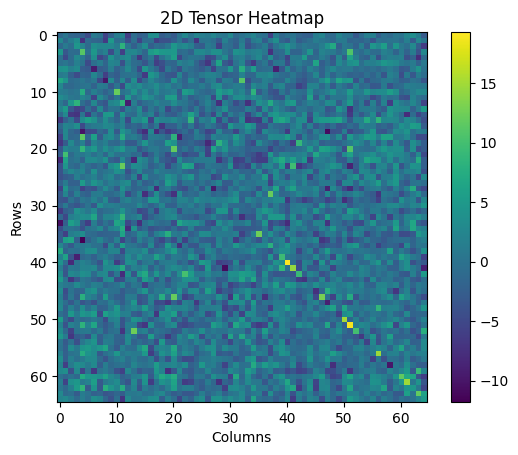

In [139]:
#print(batch_log[:100])
# for i, m in enumerate(attn_weights):
#     print(f" index {i}: {m.shape}")
with torch.no_grad():
    #heatmap = m.sa_head.query.weight @ m.sa_head.key.weight.t()
    x = torch.arange(vocab_size)
    emb = m.token_embedding_table(x)
    Q = m.sa_head.query(emb)
    K = m.sa_head.key(emb)
    heatmap = Q @ K.transpose(-2, -1)
    #heatmap = m.sa_head.query.weight.data.transpose(-2, -1) @ m.sa_head.key.weight.data
    
    plt.imshow(heatmap, cmap='viridis', interpolation='nearest')
    plt.colorbar() # Adds a scale to the right
    plt.title("2D Tensor Heatmap")
    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.show()




# for i, m in enumerate(K_log):
#     print(f" index {i}: {m.shape}")

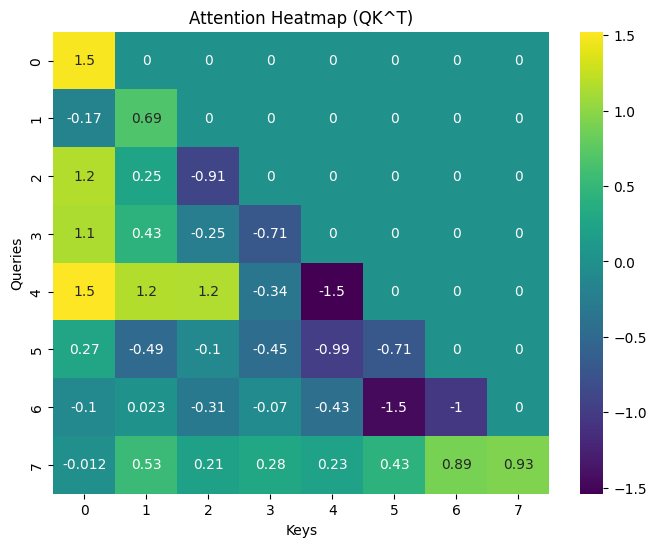

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def plot_attention_layer_weights(attn_layer_weights):
    # Ensure you have data in the log
    # pre_softmax_weights is a list of flattened tensors
    if len(attn_layer_weights) > 0:
        # Take the last recorded weight matrix (or select a specific index)
        # The shape should be (T, T)
        # Assuming T was the current sequence length at that step
        weights = attn_layer_weights[-1].detach().view(batch_size, block_size, block_size)[-1]
        # T = int(pre_softmax_weights[-1].shape[0]**0.5)
        # weights = pre_softmax_weights[-1].view(T, T).detach().cpu().numpy()
    
        plt.figure(figsize=(8, 6))
        sns.heatmap(weights, annot=True, cmap='viridis')
        plt.title("Attention Heatmap (QK^T)")
        plt.xlabel("Keys")
        plt.ylabel("Queries")
        plt.show()
    else:
        print("No attention weights logged yet. Ensure 'debug = True' and forward pass has occurred.")

plot_attention_layer_weights(pre_softmax_weights)

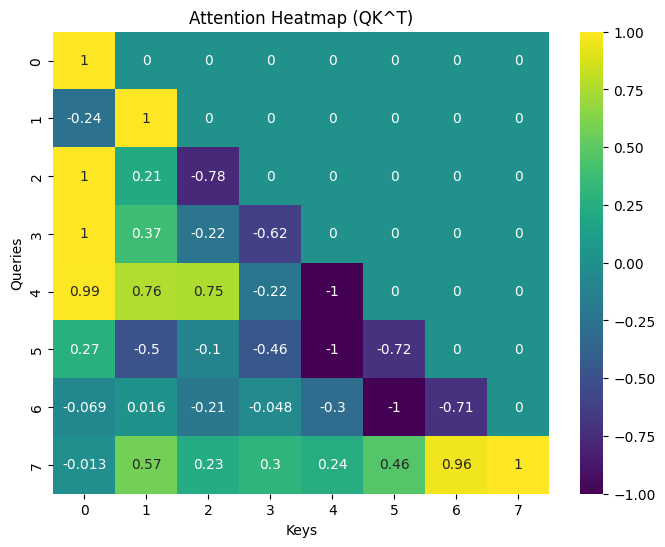

In [147]:
plot_attention_layer_weights(attn_weights)

In [102]:
import torch
import plotly.express as px

# Example 2D Tensor
tensor_2d = torch.randn(10, 10)

# Convert tensor to numpy and plot
fig = px.imshow(tensor_2d.numpy(), text_auto=True, color_continuous_scale='RdBu')
fig.update_layout(title="Interactive 2D Tensor Heatmap")
fig.show()


In [92]:
corr_n = 3
with torch.no_grad():
    top_values, top_indices = torch.topk(heatmap, k=corr_n, dim=1, largest=True)
    bottom_values, bottom_indices = torch.topk(heatmap, k=corr_n, dim=1, largest=False)
    
    print(top_values[:3], top_indices[:3])
#    print(heatmap[0, 30], heatmap[0, 62], heatmap[0, 74])
#    print(heatmap[1, 63], heatmap[1, 24], heatmap[1, 87])
    for ch in range(vocab_size):
        print(f"{itos[ch]}    ----     {decoder(top_indices[ch].tolist())}    /   {decoder(bottom_indices[ch].tolist())}")
        
    print(heatmap.shape, m.sa_head.query.weight.shape, m.sa_head.query.weight.data.shape)

tensor([[15.4173, 13.1570, 11.9853],
        [26.1234, 19.6529, 19.4101],
        [19.4019, 13.1006, 12.5998]]) tensor([[ 8, 12, 51],
        [19, 39, 17],
        [ 2, 38, 10]])

    ----     .?m    /    ,:
     ----     GaE    /   ,yt
!    ----     !Z:    /   aie
$    ----     .,a    /   qxu
&    ----     
Oz    /   tgG
'    ----      
.    /   tdg
,    ----     ,Os    /   uHq
-    ----     ';P    /   nAc
.    ----     .R
    /   A x
3    ----     pIn    /   .a;
:    ----     :!D    /   JuA
;    ----     ,;L    /   abp
?    ----     Qpt    /   ckB
A    ----     A J    /   .yX
B    ----     B;u    /   A
N
C    ----     ai.    /   ,tg
D    ----     NDW    /   
Xk
E    ----     Em
    /    ,S
F    ----     Ob:    /   ujI
G    ----     I
w    /   ntJ
H    ----     HuD    /   ,ZX
I    ----     eik    /    HO
J    ----     J N    /   y.

K    ----     x'c    /   .oX
L    ----     'Lc    /   .XO
M    ----     ubr    /   ,Ls
N    ----     Nab    /   SIy
O    ----     O.?    /    FA
P    ----

In [100]:
!pip3 install plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 46.4 MB/s eta 0:00:00m eta 0:00:010:00:01

[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [68]:
# visualize histograms of a activation values
def viz_weights(w, title):
    ww = w.view(-1, w.shape[-1])
    print(ww.shape)
    plt.figure(figsize=(20, 4)) # width and height of the plot
    legends = []
    for i, w_i in enumerate(ww): # note: exclude the output layer
        print('index %d: mean %+.2f, std %.2f, saturated: %.2f%%' % (i,  w_i.mean(), w_i.std(), (w_i.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(w_i, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'index {i}')
    
    plt.legend(legends);
    plt.title(title)
    return plt

plt = viz_weights(torch.stack(Q_log), "query batch")

RuntimeError: stack expects each tensor to be equal size, but got [32, 8, 100] at entry 0 and [1, 1, 100] at entry 1

In [28]:
# Scaled attention illustration.
B, T, C = 4, 8, 32
head_size = 16
k = torch.randn(B, T, head_size)
q = torch.randn(B, T, head_size)

In [29]:
k.mean(), k.var(), q.mean(), q.var()

(tensor(0.0003), tensor(0.8805), tensor(0.0464), tensor(0.9541))

In [30]:
wei = q@k.transpose(1,2)
wei.mean(), wei.var(), head_size



(tensor(-0.1432), tensor(14.5549), 16)

In [31]:
wei2 = q @k.transpose(1,2) / (head_size ** 0.5) 

wei2.mean(), wei2.var()

(tensor(-0.0358), tensor(0.9097))

In [ ]:
# Build single head attention layer and add to bigram.py 
